# DX 602 Week 4 Gradient Descent Animations

##  Update rule for Gradient Descent in 1 dimension:

$$
m^{(t+1)} \;=\; m^{(t)} \;-\; \eta \, \frac{\partial}{\partial m} \, \text{MSE}(m^{(t)}),
$$

where $\eta$ is the learning rate.

Since

$$
\text{MSE}(m) \;=\; \frac{1}{n} \sum_{i=1}^n \big(y_i - m x_i\big)^2,
$$

its derivative is

$$
\frac{\partial}{\partial m}\,\text{MSE}(m) \;=\; -\frac{2}{n} \sum_{i=1}^n x_i \big(y_i - m x_i\big).
$$

So the explicit update rule is:

$$
m^{(t+1)} \;=\; m^{(t)} \;+\; \eta\ \frac{2}{n} \sum_{i=1}^n x_i \Big(y_i - m^{(t)} x_i\Big).
$$

### In multiple dimensions:

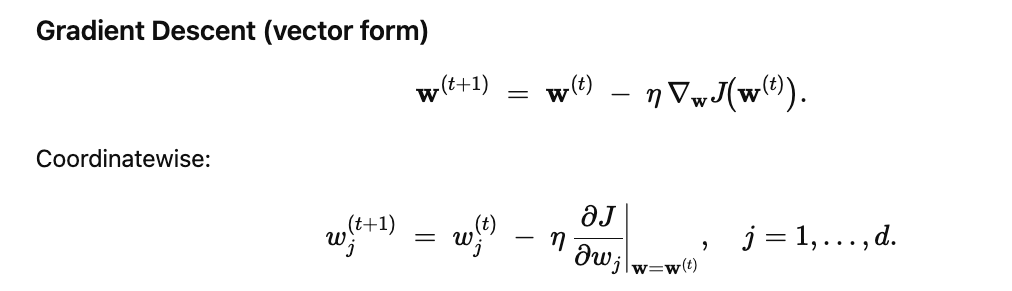

In [40]:
# %% Gradient Descent Animation with Momentum (y = m*x, no bias)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib import rc
from IPython.display import display, clear_output
import ipywidgets as widgets


rc('animation', html='jshtml')  # show animation controls inline

# ---------- data ----------
X = np.array([1,3,2,4,6,3.4,4.34,6.33,7,5,7.8,8], dtype=float)
Y = np.array([2,3,2.5,6,8.8,4.6,3.75,5.7,7,8,8.2,9], dtype=float)
n  = X.size
m_star = (X @ Y) / (X @ X)   # closed-form optimum

# loss and gradient
def mse(m):  return np.mean((Y - m*X)**2)
def grad(m): return (-2.0/n) * np.sum(X * (Y - m*X))

# fixed parabola for right plot
m_grid = np.linspace(0.4, 2.2, 300)
mse_grid = np.array([mse(m) for m in m_grid])

# figure styling
plt.rcParams.update({"font.size": 16, "lines.linewidth": 2.5, "lines.markersize": 8})

def run_trajectory(optimizer="GD", LR=0.01, BETA=0.9, M_INIT=2.0, STEPS=60):
    """Return sequence of m values under the chosen optimizer."""
    m_vals = [M_INIT]
    v = 0.0  # momentum buffer
    for _ in range(STEPS-1):
        g = grad(m_vals[-1])

        if optimizer == "GD":
            m_next = m_vals[-1] - LR * g

        elif optimizer == "Momentum":  # Classical momentum
            # v_{t+1} = beta * v_t - lr * grad
            # m_{t+1} = m_t + v_{t+1}
            v = BETA * v - LR * g
            m_next = m_vals[-1] + v

        else:
            raise ValueError("Unknown optimizer")

        m_vals.append(m_next)
    return np.array(m_vals)

def make_animation(optimizer="GD", LR=0.01, BETA=0.9, M_INIT=2.0, STEPS=60,
                   figsize=(20,10), pad=1.10):
    # ---- compute trajectory ----
    m_values = run_trajectory(optimizer=optimizer, LR=LR, BETA=BETA, M_INIT=M_INIT, STEPS=STEPS)

    # ---- build figure & artists ----
    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=figsize)

    # Left: data + line + residuals
    ax_l.set_title(f"Linear Regression:  y = m·x   ({optimizer})")
    ax_l.scatter(X, Y, color="k", label="Data")
    (line_reg,) = ax_l.plot([0, X.max()*pad], [0, M_INIT*X.max()*pad], label="Regression Line")
    residuals = [ax_l.plot([x,x], [y, M_INIT*x], color="r")[0] for x,y in zip(X,Y)]
    ax_l.set_xlim(0, X.max()*pad)
    ax_l.set_ylim(0, max(Y.max(), (M_INIT*X).max()) * pad)
    ax_l.grid(True); ax_l.set_xlabel("X"); ax_l.set_ylabel("Y")
    ax_l.legend(loc="upper right")
    text_l = ax_l.text(0.02, 0.95, "", transform=ax_l.transAxes,
                       va="top", ha="left", fontsize=18)

    # Right: MSE curve + closed-form optimum + current point
    ax_r.set_title("Mean Squared Error vs. slope m")
    ax_r.plot(m_grid, mse_grid)
    ax_r.axvline(m_star, linestyle="--", linewidth=1)
    (point,) = ax_r.plot([M_INIT], [mse(M_INIT)], "rd")
    ax_r.text(0.05, 0.92, f"m* (closed-form) = {m_star}",
              transform=ax_r.transAxes, ha="left", va="top")
    ax_r.set_xlim(m_grid.min(), m_grid.max())
    ax_r.set_ylim(0, max(mse_grid.max()*1.05, 1.0))
    ax_r.grid(True); ax_r.set_xlabel("Slope m"); ax_r.set_ylabel("MSE")

    # ---- animator ----
    def init():
        m = m_values[0]
        x_line = np.array([0, X.max()*pad])
        line_reg.set_data(x_line, m * x_line)
        for seg, x, y in zip(residuals, X, Y):
            seg.set_data([x, x], [y, m*x])
        point.set_data([m], [mse(m)])
        if optimizer == "Momentum":
            extra = f"\nβ = {BETA:.2f}"
        else:
            extra = ""
        text_l.set_text(f"iter 0\nm = {m}\nMSE = {mse(m):.4f}\nLR = {LR}{extra}")
        return [line_reg, *residuals, point, text_l]

    def update(frame):
        m = m_values[frame]
        x_line = np.array([0, X.max()*pad])
        line_reg.set_data(x_line, m * x_line)
        ax_l.set_ylim(0, max(Y.max(), (m*X).max()) * pad)
        for seg, x, y in zip(residuals, X, Y):
            seg.set_data([x, x], [y, m*x])
        point.set_data([m], [mse(m)])
        if optimizer == "Momentum":
            extra = f"\nβ = {BETA:.2f}"
        else:
            extra = ""
        text_l.set_text(f"iter {frame}\nm = {m:.4f}\nMSE = {mse(m):.4f}\nLR = {LR}{extra}")
        return [line_reg, *residuals, point, text_l]

    anim = FuncAnimation(fig, update, frames=len(m_values), init_func=init,
                         blit=False, interval=200)
    plt.close(fig)
    return anim

# ---- widgets ----
opt_dd = widgets.Dropdown(options=["GD", "Momentum"], value="GD", description="Optimizer")
lr_slider = widgets.FloatLogSlider(value=0.003, base=10, min=-4, max=0, step=0.05,
                                   continuous_update=False, description='LR', readout_format='.4f')
beta_slider = widgets.FloatSlider(value=0.90, min=0.0, max=0.99, step=0.01,
                                  continuous_update=False, description='β (momentum)')
m0_slider = widgets.FloatSlider(value=2.0, min=-3.0, max=3.0, step=0.05,                                         ### <<<<<<<<<<<
                                continuous_update=False, description='m₀')
steps_slider = widgets.IntSlider(value=60, min=10, max=200, step=5, description='Steps')

# only show beta when Momentum is selected
def toggle_beta_visibility(*_):
    beta_slider.layout.display = 'flex' if opt_dd.value == "Momentum" else 'none'
opt_dd.observe(toggle_beta_visibility, names='value')
toggle_beta_visibility()

ui = widgets.HBox([opt_dd, lr_slider, beta_slider, m0_slider, steps_slider])
out = widgets.Output()

def redraw(_=None):
    with out:
        clear_output(wait=True)
        anim = make_animation(optimizer=opt_dd.value,
                              LR=lr_slider.value, BETA=beta_slider.value,
                              M_INIT=m0_slider.value, STEPS=steps_slider.value)
        display(anim)

        

for w in [opt_dd, lr_slider, beta_slider, m0_slider, steps_slider]:
    w.observe(redraw, names='value')

display(widgets.VBox([ui, out]))
redraw()


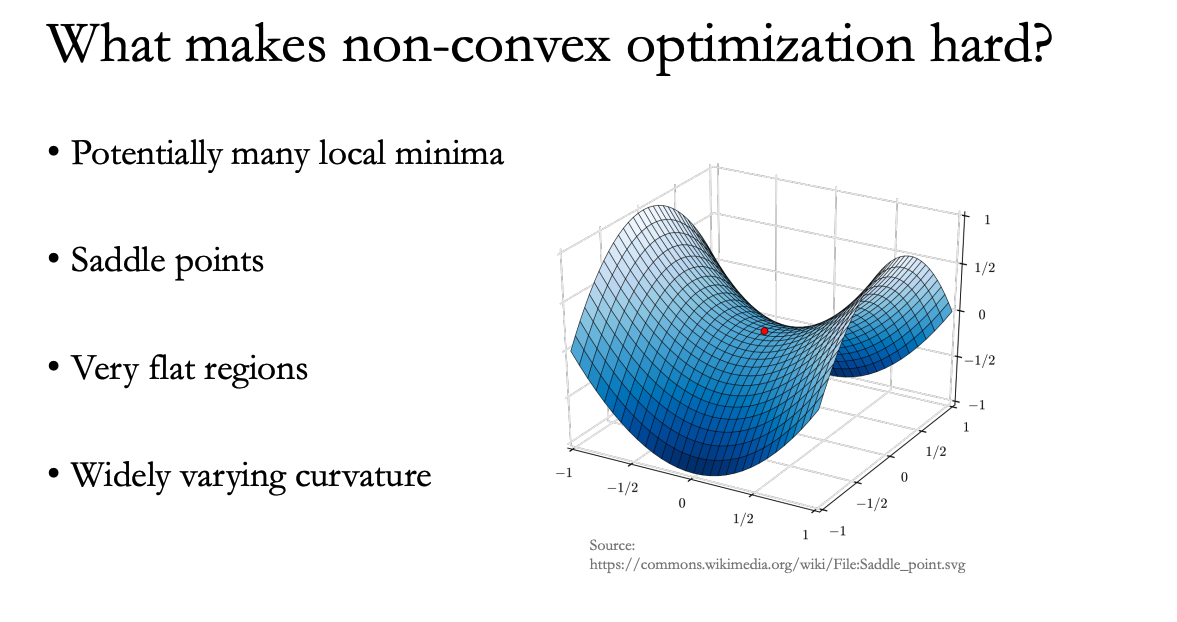

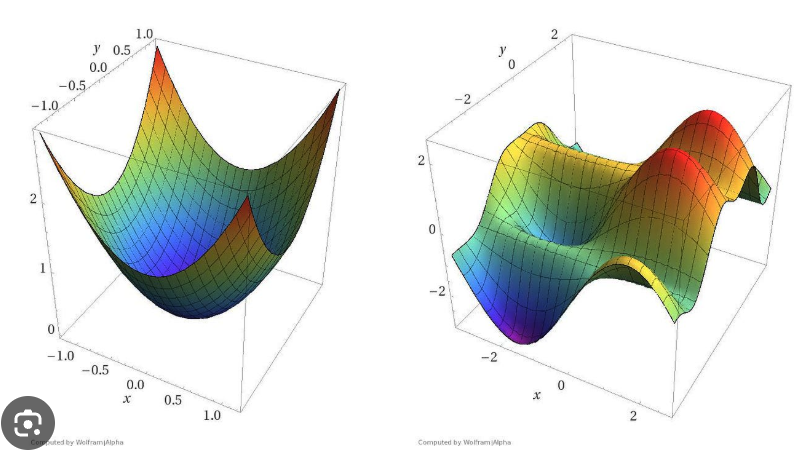



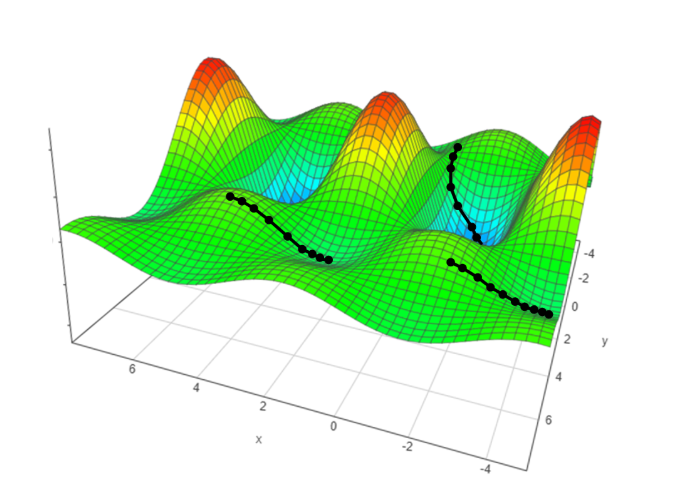

### One solution: Momentum!     

#### The Classical Momentum update rule can be written (in 1 dimension) like this:

$$
\begin{aligned}
v_{t+1} &= \beta v_t \;-\;\eta \,\nabla J(m_t), \\
m_{t+1} &= m_t + v_{t+1},
\end{aligned}
$$

where

* $m_t$ is the parameter at iteration $t$,
* $v_t$ is the velocity (the momentum term),
* $\beta \in [0,1)$ is the momentum coefficient,
* $\eta$ is the learning rate,
* $\nabla J(m_t)$ is the gradient of the objective at $m_t$.



In [41]:
# %% Nonconvex 1D Optimization: GD vs Momentum (single plot)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib import rc
from IPython.display import display, clear_output
import ipywidgets as widgets

rc('animation', html='jshtml')  # show player inline

# ----------- define a rugged, nonconvex function f(m) -----------
# f(m) = 1/4 m^4 - 1/2 m^2 + 0.1 m + 0.2 sin(3 m)
# Has multiple local minima; one global minimum.
def f(m):
    return 0.25*m**4 - 0.5*m**2 + 0.1*m + 0.2*np.sin(3*m)

def df(m):
    return m**3 - m + 0.1 + 0.6*np.cos(3*m)

# Plot domain
M_MIN, M_MAX = -3.0, 3.0
m_grid = np.linspace(M_MIN, M_MAX, 1000)
f_grid = f(m_grid)
# approximate global minimum on grid (for visual marker)
m_star = m_grid[np.argmin(f_grid)]
f_star = f(m_star)

# put this near the top of the cell (global slot to hold the animation)
_last_anim = None


# global style
plt.rcParams.update({"font.size": 12, "lines.linewidth": 2.5, "lines.markersize": 8})

def run_trajectory(optimizer="GD", LR=0.01, BETA=0.9, M_INIT=2.0, STEPS=120, clip=(M_MIN, M_MAX)):
    """Return sequence of m values under chosen optimizer on f."""
    m_vals = [float(M_INIT)]
    v = 0.0  # momentum buffer
    for _ in range(STEPS-1):
        g = df(m_vals[-1])

        if optimizer == "GD":
            m_next = m_vals[-1] - LR * g

        elif optimizer == "Momentum":  # Classical momentum
            v = BETA * v - LR * g
            m_next = m_vals[-1] + v
        else:
            raise ValueError("Unknown optimizer")

        # keep inside bounds (prevents runaway when LR is huge)
        if clip is not None:
            m_next = np.clip(m_next, clip[0], clip[1])

        m_vals.append(m_next)
    return np.array(m_vals)

def make_animation(optimizer="Momentum", LR=0.02, BETA=0.9, M_INIT=2.0, STEPS=120,
                   figsize=(10,5)):
    # ---- compute trajectory ----
    m_values = run_trajectory(optimizer=optimizer, LR=LR, BETA=BETA, M_INIT=M_INIT, STEPS=STEPS)

    # ---- build figure ----
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    ax.set_title(f"Nonconvex Optimization: {optimizer}")
    ax.plot(m_grid, f_grid, label="f(m)")
    ax.axvline(m_star, linestyle="--", linewidth=1, label="global min (grid)")
    ax.plot([m_star], [f_star], "ko", ms=6)

    (pt,) = ax.plot([m_values[0]], [f(m_values[0])], "rd", label="iterate")
    # optional: path trace
    (path_line,) = ax.plot([m_values[0]], [f(m_values[0])], "-", alpha=0.5)

    ax.set_xlim(M_MIN, M_MAX)
    # add a little headroom for text box
    ax.set_ylim(min(f_grid)-0.5, max(f_grid)+0.5)
    ax.grid(True)
    ax.set_xlabel("m"); ax.set_ylabel("f(m)")
    ax.legend(loc="upper right")

    # text overlay with state
    text = ax.text(0.02, 0.95, "", transform=ax.transAxes, va="top", ha="left")

    def init():
        m = m_values[0]
        pt.set_data([m], [f(m)])
        path_line.set_data([m], [f(m)])
        extra = (f"\nβ = {BETA:.2f}" if optimizer == "Momentum" else "")
        text.set_text(f"iter 0\nm = {m:.4f}\nf(m) = {f(m):.4f}\nLR = {LR}{extra}")
        return [pt, path_line, text]

    def update(frame):
        m = m_values[frame]
        pt.set_data([m], [f(m)])
        # Extend the path line to current frame (nice breadcrumb effect)
        path_line.set_data(m_values[:frame+1], f(m_values[:frame+1]))
        extra = (f"\nβ = {BETA:.2f}" if optimizer == "Momentum" else "")
        text.set_text(f"iter {frame}\nm = {m:.4f}\nf(m) = {f(m):.4f}\nLR = {LR}{extra}")
        return [pt, path_line, text]

    anim = FuncAnimation(fig, update, frames=len(m_values), init_func=init,
                         blit=False, interval=120)
    plt.close(fig)
    return anim

# ---- widgets ----
opt_dd = widgets.Dropdown(options=["GD", "Momentum"], value="GD", description="Optimizer")
lr_slider = widgets.FloatLogSlider(value=0.02, base=10, min=-4, max=0, step=0.05,
                                   continuous_update=False, description='LR', readout_format='.4f')
beta_slider = widgets.FloatSlider(value=0.90, min=0.0, max=0.99, step=0.01,
                                  continuous_update=False, description='β (momentum)')
m0_slider = widgets.FloatSlider(value=2.0, min=-3.0, max=3.0, step=0.05,                           ##       <<<<<====================
                                continuous_update=False, description='m₀')
steps_slider = widgets.IntSlider(value=120, min=20, max=400, step=5, description='Steps')

def toggle_beta_visibility(*_):
    beta_slider.layout.display = 'flex' if opt_dd.value == "Momentum" else 'none'
opt_dd.observe(toggle_beta_visibility, names='value')
toggle_beta_visibility()

ui = widgets.HBox([opt_dd, lr_slider, beta_slider, m0_slider, steps_slider])
out = widgets.Output()

# # Make the output area tall enough and allow overflow to show
# out.layout.height = '800px'        # adjust to taste (e.g., '700px')
# out.layout.overflow_y = 'auto'     # scroll if needed
# out.layout.overflow_x = 'visible'

# strong refs to prevent GC
_last_anim = None
_last_html = None
_display_id = f"anim-{uuid.uuid4()}"

def redraw(_=None):
    global _last_anim, _last_html
    # 1) build the animation (NO plt.show(); inside make_animation keep plt.close(fig))
    anim = make_animation(optimizer=opt_dd.value,
                          LR=lr_slider.value, BETA=beta_slider.value,
                          M_INIT=m0_slider.value, STEPS=steps_slider.value)
    _last_anim = anim

    # 2) render to HTML *before* touching the output area
    html = anim.to_jshtml()
    _last_html = html

    with out:
        # IMPORTANT: do NOT clear after display; update the same display instead
        if not getattr(redraw, "_did_first", False):
            display(HTML(html), display_id=_display_id)
            redraw._did_first = True
        else:
            update_display(HTML(html), display_id=_display_id)

# hook up callbacks
for w in [opt_dd, lr_slider, beta_slider, m0_slider, steps_slider]:
    w.observe(redraw, names='value')

display(widgets.VBox([ui, out]))
redraw()



In [28]:
# %% Nonconvex 1D Optimization: GD vs Momentum (single plot)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib import rc
from IPython.display import display, clear_output
import ipywidgets as widgets

rc('animation', html='jshtml')  # show player inline

# ----------- define a rugged, nonconvex function f(m) -----------
# f(m) = 1/4 m^4 - 1/2 m^2 + 0.1 m + 0.2 sin(3 m)
# Has multiple local minima; one global minimum.
def f(m):
    return 0.25*m**4 - 0.5*m**2 + 0.1*m + 0.2*np.sin(3*m)

def df(m):
    return m**3 - m + 0.1 + 0.6*np.cos(3*m)

# Plot domain
M_MIN, M_MAX = -3.0, 3.0
m_grid = np.linspace(M_MIN, M_MAX, 1000)
f_grid = f(m_grid)
# approximate global minimum on grid (for visual marker)
m_star = m_grid[np.argmin(f_grid)]
f_star = f(m_star)

# put this near the top of the cell (global slot to hold the animation)
_last_anim = None


# global style
plt.rcParams.update({"font.size": 12, "lines.linewidth": 2.5, "lines.markersize": 8})

def run_trajectory(optimizer="GD", LR=0.01, BETA=0.9, M_INIT=2.0, STEPS=120, clip=(M_MIN, M_MAX)):
    """Return sequence of m values under chosen optimizer on f."""
    m_vals = [float(M_INIT)]
    v = 0.0  # momentum buffer
    for _ in range(STEPS-1):
        g = df(m_vals[-1])

        if optimizer == "GD":
            m_next = m_vals[-1] - LR * g

        elif optimizer == "Momentum":  # Classical momentum
            v = BETA * v - LR * g
            m_next = m_vals[-1] + v
        else:
            raise ValueError("Unknown optimizer")

        # keep inside bounds (prevents runaway when LR is huge)
        if clip is not None:
            m_next = np.clip(m_next, clip[0], clip[1])

        m_vals.append(m_next)
    return np.array(m_vals)

def make_animation(optimizer="Momentum", LR=0.02, BETA=0.9, M_INIT=2.0, STEPS=120,
                   figsize=(10,5)):
    # ---- compute trajectory ----
    m_values = run_trajectory(optimizer=optimizer, LR=LR, BETA=BETA, M_INIT=M_INIT, STEPS=STEPS)

    # ---- build figure ----
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    ax.set_title(f"Nonconvex Optimization: {optimizer}")
    ax.plot(m_grid, f_grid, label="f(m)")
    ax.axvline(m_star, linestyle="--", linewidth=1, label="global min (grid)")
    ax.plot([m_star], [f_star], "ko", ms=6)

    (pt,) = ax.plot([m_values[0]], [f(m_values[0])], "rd", label="iterate")
    # optional: path trace
    (path_line,) = ax.plot([m_values[0]], [f(m_values[0])], "-", alpha=0.5)

    ax.set_xlim(M_MIN, M_MAX)
    # add a little headroom for text box
    ax.set_ylim(min(f_grid)-0.5, max(f_grid)+0.5)
    ax.grid(True)
    ax.set_xlabel("m"); ax.set_ylabel("f(m)")
    ax.legend(loc="upper right")

    # text overlay with state
    text = ax.text(0.02, 0.95, "", transform=ax.transAxes, va="top", ha="left")

    def init():
        m = m_values[0]
        pt.set_data([m], [f(m)])
        path_line.set_data([m], [f(m)])
        extra = (f"\nβ = {BETA:.2f}" if optimizer == "Momentum" else "")
        text.set_text(f"iter 0\nm = {m:.4f}\nf(m) = {f(m):.4f}\nLR = {LR}{extra}")
        return [pt, path_line, text]

    def update(frame):
        m = m_values[frame]
        pt.set_data([m], [f(m)])
        # Extend the path line to current frame (nice breadcrumb effect)
        path_line.set_data(m_values[:frame+1], f(m_values[:frame+1]))
        extra = (f"\nβ = {BETA:.2f}" if optimizer == "Momentum" else "")
        text.set_text(f"iter {frame}\nm = {m:.4f}\nf(m) = {f(m):.4f}\nLR = {LR}{extra}")
        return [pt, path_line, text]

    anim = FuncAnimation(fig, update, frames=len(m_values), init_func=init,
                         blit=False, interval=120)
    plt.close(fig)
    return anim

# ---- widgets ----
opt_dd = widgets.Dropdown(options=["GD", "Momentum"], value="Momentum", description="Optimizer")
lr_slider = widgets.FloatLogSlider(value=0.02, base=10, min=-4, max=0, step=0.05,
                                   continuous_update=False, description='LR', readout_format='.4f')
beta_slider = widgets.FloatSlider(value=0.90, min=0.0, max=0.99, step=0.01,
                                  continuous_update=False, description='β (momentum)')
m0_slider = widgets.FloatSlider(value=2.0, min=-3.0, max=3.0, step=0.05,
                                continuous_update=False, description='m₀')
steps_slider = widgets.IntSlider(value=120, min=20, max=400, step=5, description='Steps')

def toggle_beta_visibility(*_):
    beta_slider.layout.display = 'flex' if opt_dd.value == "Momentum" else 'none'
opt_dd.observe(toggle_beta_visibility, names='value')
toggle_beta_visibility()

ui = widgets.HBox([opt_dd, lr_slider, beta_slider, m0_slider, steps_slider])
out = widgets.Output()

# # Make the output area tall enough and allow overflow to show
# out.layout.height = '800px'        # adjust to taste (e.g., '700px')
# out.layout.overflow_y = 'auto'     # scroll if needed
# out.layout.overflow_x = 'visible'

# strong refs to prevent GC
_last_anim = None
_last_html = None
_display_id = f"anim-{uuid.uuid4()}"

def redraw(_=None):
    global _last_anim, _last_html
    # 1) build the animation (NO plt.show(); inside make_animation keep plt.close(fig))
    anim = make_animation(optimizer=opt_dd.value,
                          LR=lr_slider.value, BETA=beta_slider.value,
                          M_INIT=m0_slider.value, STEPS=steps_slider.value)
    _last_anim = anim

    # 2) render to HTML *before* touching the output area
    html = anim.to_jshtml()
    _last_html = html

    with out:
        # IMPORTANT: do NOT clear after display; update the same display instead
        if not getattr(redraw, "_did_first", False):
            display(HTML(html), display_id=_display_id)
            redraw._did_first = True
        else:
            update_display(HTML(html), display_id=_display_id)

# hook up callbacks
for w in [opt_dd, lr_slider, beta_slider, m0_slider, steps_slider]:
    w.observe(redraw, names='value')

display(widgets.VBox([ui, out]))
redraw()



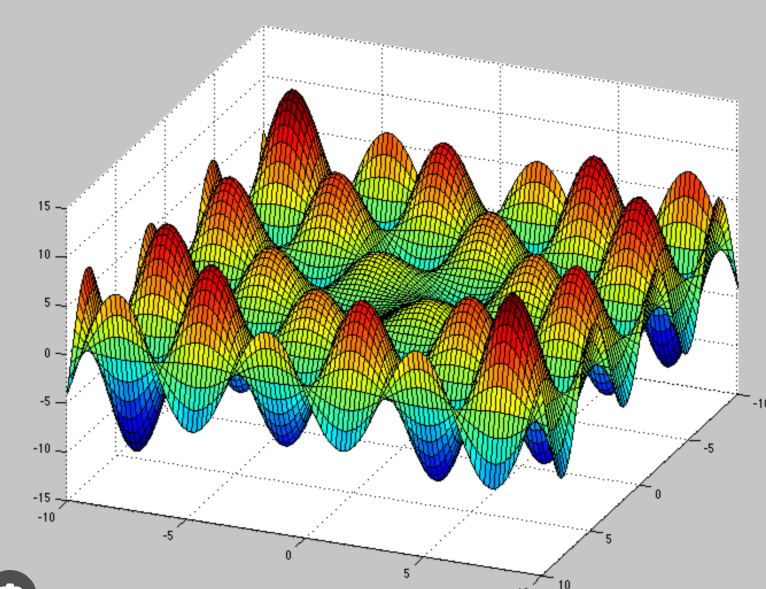

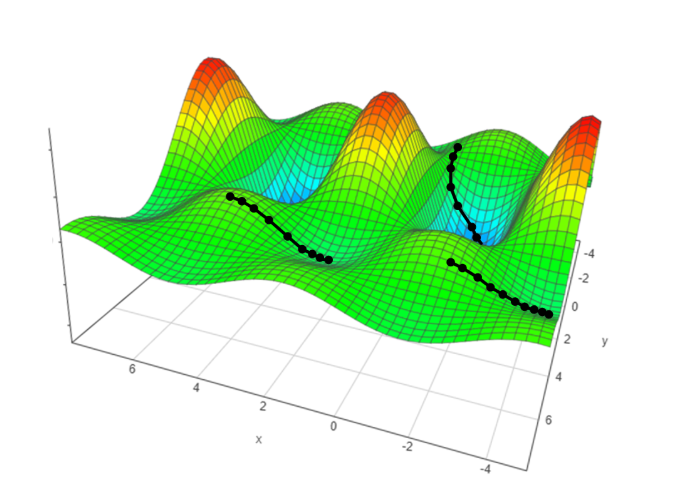